# 1. Train RNN on head-direction task

This notebook trains the RNN to integrate angular velocity into the corresponding heading angle, then records its hidden states for the IMD analysis (notebooks 02 and 03).

The functions come from `src/rnn/`.

Chosen hyperparameters:  
- 64 hidden units (GRU)
- dt = 20 ms
- 200 steps per training sequence (4 s), batches of 128
- 3000 training steps
- Adam, learning rate 0.003 with cosine decay to 0 (a constant rate leaves loss spikes and a worse model)
- test sequences: 600 steps (12 s)

In [18]:
import sys
from pathlib import Path

# permet d'importer les modules de src/rnn depuis ce notebook
REPO_ROOT = Path.cwd().parent
sys.path.append(str(REPO_ROOT / "src" / "rnn"))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from data import generate_batch
from model import HeadDirectionRNN
from train import train
from simulate import simulate

## Training

Each sequence starts from a random initial angle $\theta_0$, drawn uniformly in $[-\pi, \pi)$. $\theta_0$ is not an input: it sets the initial hidden state $h_0 = \tanh(W_\text{enc}[\cos\theta_0, \sin\theta_0])$. The RNN is then fed angular velocities and outputs $(\cos\theta, \sin\theta)$ at each step. The loss is the MSE on these outputs.

Why a random $\theta_0$: with $\theta_0 = 0$ for every sequence, the network encodes the unwrapped angle (a helix, not a ring; see `results/figures/helix_not_ring.png`).

Model is saved in `results/models/head_direction_rnn_ring.pt`.

step     0 | loss 0.50988
step   300 | loss 0.00624
step   600 | loss 0.00059
step   900 | loss 0.01483
step  1200 | loss 0.00024
step  1500 | loss 0.00067
step  1800 | loss 0.00024
step  2100 | loss 0.00011
step  2400 | loss 0.00016
step  2700 | loss 0.00022
step  2999 | loss 0.00007
saved trained model to /Users/GwenBeulque/imd-neuro-template/ProjMa2/results/models/head_direction_rnn_ring.pt


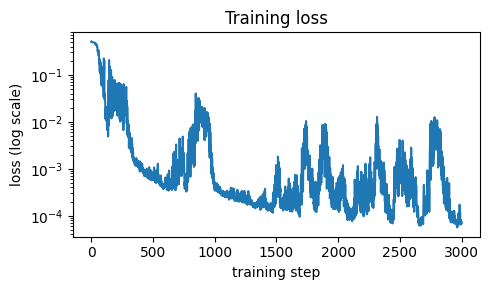

In [19]:
RANDOM_THETA0 = True

model, losses = train(n_steps=3000, seq_len=200, log_every=300, random_theta0=RANDOM_THETA0)

plt.figure(figsize=(5,3))
plt.plot(losses)
plt.yscale("log")
plt.xlabel("training step")
plt.ylabel("loss (log scale)")
plt.title("Training loss")
plt.tight_layout()
plt.show()

## Simulation

Run the model on 500 new sequences of 600 steps (3× longer than in training) and save the trajectories of the hidden state h_t to `data/simulated/head_direction_trajectories_ring.npz`. This gives the data used for IMD.

This file (80 MB) is not saved in git. After a fresh clone, run the import cell and then this cell only (no need to retrain): it reloads the saved model and regenerates exactly the same trajectories (fixed seed).

In [20]:
hidden_states, theta = simulate(n_sequences=500, seq_len=600, random_theta0=RANDOM_THETA0)
print("hidden_states shape:", hidden_states.shape)  # (n_sequences, seq_len, hidden_size)
print("theta shape:", theta.shape)

saved 500 trajectories of length 600 to /Users/GwenBeulque/imd-neuro-template/ProjMa2/data/simulated/head_direction_trajectories_ring.npz
hidden_states shape: torch.Size([500, 600, 64])
hidden_states shape: (500, 600, 64)
theta shape: (500, 600)


## Verification: is the angle encoded in the hidden states?

Project the data points using PCA and color them based on their real angle theta. Expect a ring in PC1–PC2, with the color going around exactly once.

variance expliquée (3 premières PC): [0.40174657 0.3802901  0.10964666]


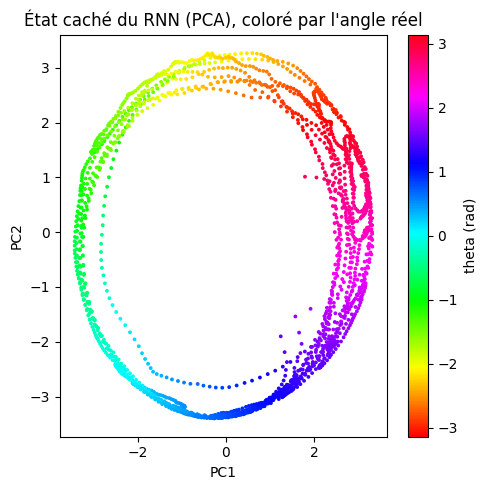

In [21]:
h_flat = hidden_states.reshape(-1, hidden_states.shape[-1])
theta_flat = np.angle(np.exp(1j * theta.reshape(-1)))  # cap replié dans [-pi, pi) pour la couleur

pca = PCA(n_components=3)
h_pca = pca.fit_transform(h_flat)
print("variance expliquée (3 premières PC):", pca.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(5, 5))
sc = ax.scatter(h_pca[:2000, 0], h_pca[:2000, 1], c=theta_flat[:2000], cmap="hsv", s=3)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("État caché du RNN (PCA), coloré par l'angle réel")
plt.colorbar(sc, label="theta (rad)")
plt.tight_layout()
plt.show()

## Qualitative sanity check: 1 trajectory, velocity vs predicted/true angle

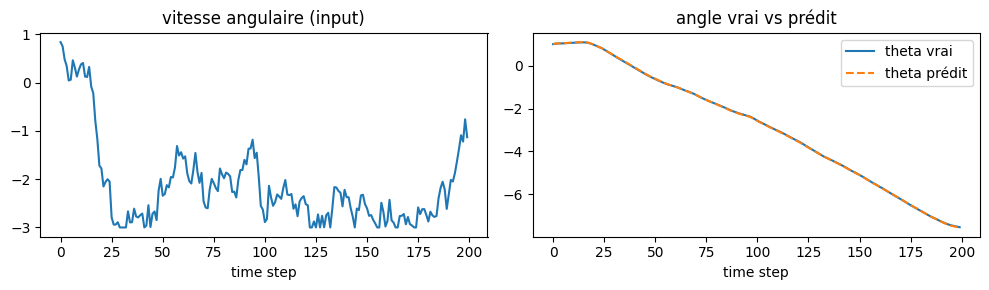

In [22]:
import torch

theta0_check = np.array([1.0], dtype=np.float32) if RANDOM_THETA0 else None
velocity, target, theta_check = generate_batch(batch_size=1, seq_len=200, seed=7, theta0=theta0_check)
with torch.no_grad():
    pred, _ = model(velocity, theta0=None if theta0_check is None else torch.from_numpy(theta0_check))

t = range(200)
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(t, velocity[0, :, 0].numpy())
axes[0].set_title("vitesse angulaire (input)")
axes[0].set_xlabel("time step")

axes[1].plot(t, theta_check[0].numpy(), label="theta vrai")
theta_pred = torch.atan2(pred[0, :, 1], pred[0, :, 0]).numpy()
axes[1].plot(t, np.unwrap(theta_pred), "--", label="theta prédit")
axes[1].set_title("angle vrai vs prédit")
axes[1].set_xlabel("time step")
axes[1].legend()
plt.tight_layout()
plt.show()

## Simple check: how accurate is the model?

Angular error between predicted and true angle on the 500 test sequences (wrapped to [0°, 180°]). A random guess would give 90° on average.

In [ ]:
suffix = "_ring" if RANDOM_THETA0 else ""
test = np.load(REPO_ROOT / "data" / "simulated" / f"head_direction_trajectories{suffix}.npz")
theta_pred_test = np.arctan2(test["pred"][..., 1], test["pred"][..., 0])
err = np.degrees(np.abs(np.angle(np.exp(1j * (theta_pred_test - test["theta"])))))

print(f"mean error: {err.mean():.2f}°   (random guess: 90°)")
print(f"steps with error < 5°: {100 * (err < 5).mean():.1f} %")